In [1]:
import pandas as pd
import numpy as np



In [2]:
df_matches = pd.read_csv('matches.csv')
df_deliveries= pd.read_csv('deliveries.csv')




In [3]:
#rename
df_matches = df_matches.rename(columns={'id': 'match_id'})

#merge
df = pd.merge(df_deliveries, df_matches, on='match_id')



In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 38 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

In [5]:

print("Dataset Shape (Rows, Columns):", df.shape)

print("\n Column Names ")
print(df.columns.tolist())

print("\n Data Types ")
print(df.dtypes)


total_seasons = df['season'].nunique()
print(f"\n Total Seasons Covered ")
print(f"There are {total_seasons} seasons covered in this dataset.")

Dataset Shape (Rows, Columns): (150460, 38)

 Column Names 
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

 Data Types 
match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batsman             object
non_striker         object
bowler              object
is_super_over        int64
wide_runs            int64
bye_runs             int64
legbye_runs          int64
noball_runs          int64
penalty_runs         int64
batsman_runs         int64
ex

In [6]:
#question 2 
missing_values = df.isnull().sum()


print(" Columns with missing values ")
print(missing_values[missing_values > 0])

 Columns with missing values 
player_dismissed    143022
dismissal_kind      143022
fielder             145091
city                  1700
winner                 321
player_of_match        321
umpire1                248
umpire2                248
umpire3             150460
dtype: int64


In [7]:
df['city'] = df['city'].fillna('Unknown')
print("Missing cities after fixing:", df['city'].isnull().sum())

Missing cities after fixing: 0


In [8]:
df['player_of_match'] = df['player_of_match'].fillna('Not Awarded')
print("Missing player_of_match after fixing:", df['player_of_match'].isnull().sum())

Missing player_of_match after fixing: 0


In [9]:
df['dismissal_kind'] = df['dismissal_kind'].fillna('not out')
print("Missing dismissal_kind after fixing:", df['dismissal_kind'].isnull().sum())

Missing dismissal_kind after fixing: 0


In [10]:
#question 3 
df['total_runs'] = df['batsman_runs'] + df['extra_runs']
df['is_boundary'] = np.where(df['batsman_runs'] >= 4, 'boundary', 'non-boundary')
print(df[['batsman_runs', 'extra_runs', 'total_runs', 'is_boundary']].head())




# 2. Creating the 'is_boundary' column using NumPy
# np.where works like this: np.where(condition, value_if_true, value_if_false)

   batsman_runs  extra_runs  total_runs   is_boundary
0             0           0           0  non-boundary
1             0           0           0  non-boundary
2             4           0           4      boundary
3             0           0           0  non-boundary
4             0           2           2  non-boundary


In [29]:
def categorize_over(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle'
    else:
        return 'Death'


df['over_phase'] = df['over'].apply(categorize_over)

print("Feature Engineering complete!")

print(df[['total_runs', 'is_boundary', 'over', 'over_phase']].head())

Feature Engineering complete!
   total_runs   is_boundary  over over_phase
0           0  non-boundary     1  Powerplay
1           0  non-boundary     1  Powerplay
2           4      boundary     1  Powerplay
3           0  non-boundary     1  Powerplay
4           2  non-boundary     1  Powerplay


In [12]:
#question 4 
top_batsmen = df.groupby('batsman')['batsman_runs'].sum()
top_5_batsmen = top_batsmen.sort_values(ascending=False).head(5)

print("Top 5 Batsmen by Total Runs")
print(top_5_batsmen)

Top 5 Batsmen by Total Runs
batsman
SK Raina     4548
V Kohli      4423
RG Sharma    4207
G Gambhir    4132
DA Warner    4014
Name: batsman_runs, dtype: int64


In [13]:


bowler_stats = df.groupby('bowler').filter(lambda x: len(x) >= 500)

economy = bowler_stats.groupby('bowler').apply(
    lambda x: np.round(x['total_runs'].sum() / (len(x) / 6), 2),
    include_groups=False
).reset_index(name='economy_rate')


print("Top 5 Bowlers by Economy Rate")
print(economy.sort_values(by='economy_rate').head(5))

--- Top 5 Bowlers by Economy Rate ---
            bowler  economy_rate
76       SP Narine          6.40
60        R Ashwin          6.49
21        DW Steyn          6.60
0         A Kumble          6.65
42  M Muralitharan          6.70


In [31]:

bowler_stats = df.groupby('bowler').filter(lambda x: len(x) >= 500)


economy = bowler_stats.groupby('bowler').apply(
    lambda x: np.round(x['total_runs'].sum() / (len(x) / 6), 2),
    include_groups=False
).reset_index(name='economy_rate')


print ("Top 5 Bowlers by Economy Rate")
print(economy.sort_values(by='economy_rate').head(5))

Top 5 Bowlers by Economy Rate
            bowler  economy_rate
76       SP Narine          6.40
60        R Ashwin          6.49
21        DW Steyn          6.60
0         A Kumble          6.65
42  M Muralitharan          6.70


In [32]:

matches_only = df.drop_duplicates(subset=['match_id']).copy()

wins = matches_only.groupby(['season', 'winner']).size().reset_index(name='total_wins')
wins = wins.rename(columns={'winner': 'team'})


team1_matches = matches_only.groupby(['season', 'team1']).size().reset_index(name='plays')
team1_matches = team1_matches.rename(columns={'team1': 'team'})

team2_matches = matches_only.groupby(['season', 'team2']).size().reset_index(name='plays')
team2_matches = team2_matches.rename(columns={'team2': 'team'})


import pandas as pd 
total_played = pd.concat([team1_matches, team2_matches]).groupby(['season', 'team'])['plays'].sum().reset_index(name='total_matches')

print(" Wins and Total Matches counted!")
print(total_played.head())

 Wins and Total Matches counted!
   season                   team  total_matches
0    2008    Chennai Super Kings             16
1    2008        Deccan Chargers             14
2    2008       Delhi Daredevils             14
3    2008        Kings XI Punjab             15
4    2008  Kolkata Knight Riders             13


In [33]:
win_stats = pd.merge(total_played, wins, on=['season', 'team'], how='left')
win_stats['total_wins'] = win_stats['total_wins'].fillna(0)
win_stats['win_percentage'] = np.round((win_stats['total_wins'] / win_stats['total_matches']) * 100, 2)
highest_win_pct = win_stats.sort_values('win_percentage', ascending=False).drop_duplicates('season').sort_values('season')

print("Team with Highest Win Percentage per Season")
print(highest_win_pct[['season', 'team', 'total_matches', 'total_wins', 'win_percentage']].to_string(index=False))

Team with Highest Win Percentage per Season
 season                  team  total_matches  total_wins  win_percentage
   2008      Rajasthan Royals             16          13           81.25
   2009      Delhi Daredevils             15          10           66.67
   2010        Mumbai Indians             16          11           68.75
   2011   Chennai Super Kings             16          11           68.75
   2012 Kolkata Knight Riders             17          12           70.59
   2013        Mumbai Indians             19          13           68.42
   2014       Kings XI Punjab             17          12           70.59
   2015        Mumbai Indians             16          10           62.50
   2016   Sunrisers Hyderabad             17          11           64.71
   2017        Mumbai Indians             17          12           70.59


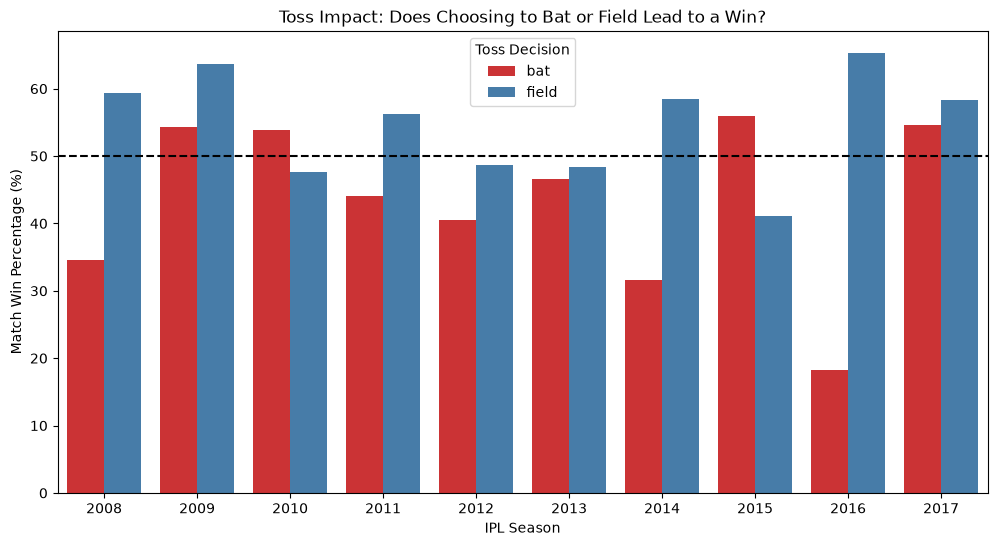

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
matches_only = df.drop_duplicates(subset=['match_id']).copy()
matches_only['toss_winner_is_winner'] = matches_only['toss_winner'] == matches_only['winner']
toss_impact = matches_only.groupby(['season', 'toss_decision'])['toss_winner_is_winner'].mean().reset_index()
toss_impact['win_percentage'] = toss_impact['toss_winner_is_winner'] * 100
plt.figure(figsize=(12, 6))
sns.barplot(data=toss_impact, x='season', y='win_percentage', hue='toss_decision', palette='Set1')

plt.title('Toss Impact: Does Choosing to Bat or Field Lead to a Win?')
plt.xlabel('IPL Season')
plt.ylabel('Match Win Percentage (%)')
plt.axhline(50, color='black', linestyle='--')
plt.legend(title='Toss Decision')
plt.show()

/tmp/ipykernel_4392/887297141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_batsmen.values, y=top_10_batsmen.index, palette='viridis')


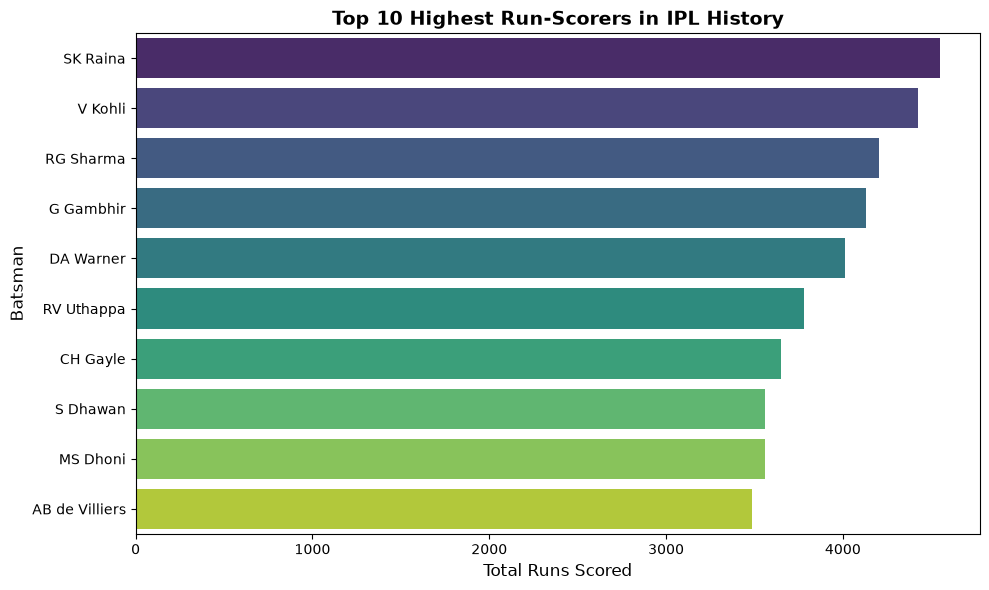

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
top_10_batsmen = df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_batsmen.values, y=top_10_batsmen.index, palette='viridis')
plt.title('Top 10 Highest Run-Scorers in IPL History', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs Scored', fontsize=12)
plt.ylabel('Batsman', fontsize=12)
plt.tight_layout()
plt.show()

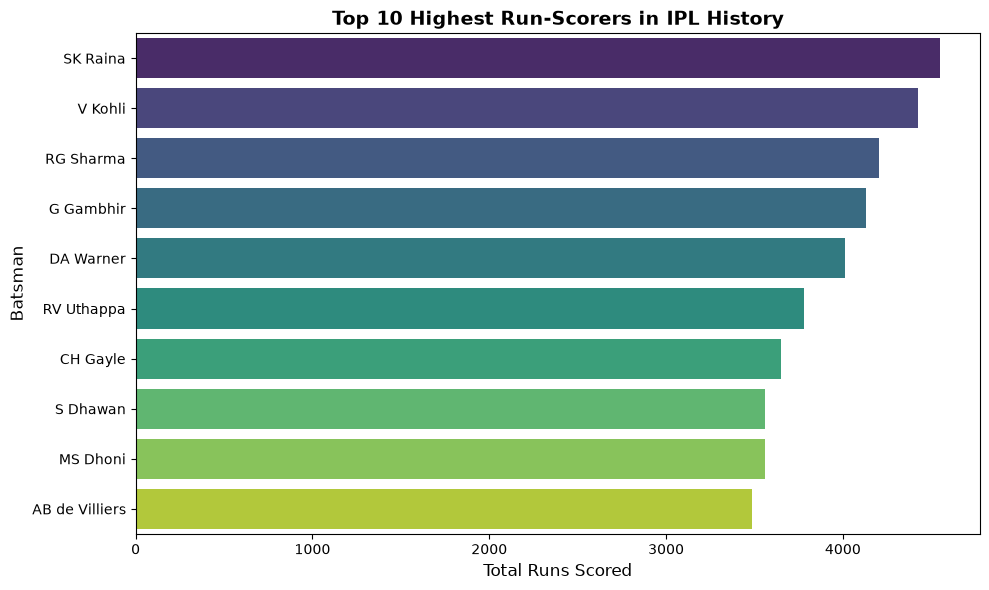

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
top_10_batsmen = df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_10_batsmen.values, 
    y=top_10_batsmen.index, 
    hue=top_10_batsmen.index,
    palette='viridis', 
    legend=False              
)


plt.title('Top 10 Highest Run-Scorers in IPL History', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs Scored', fontsize=12)
plt.ylabel('Batsman', fontsize=12)
plt.tight_layout()
plt.show()

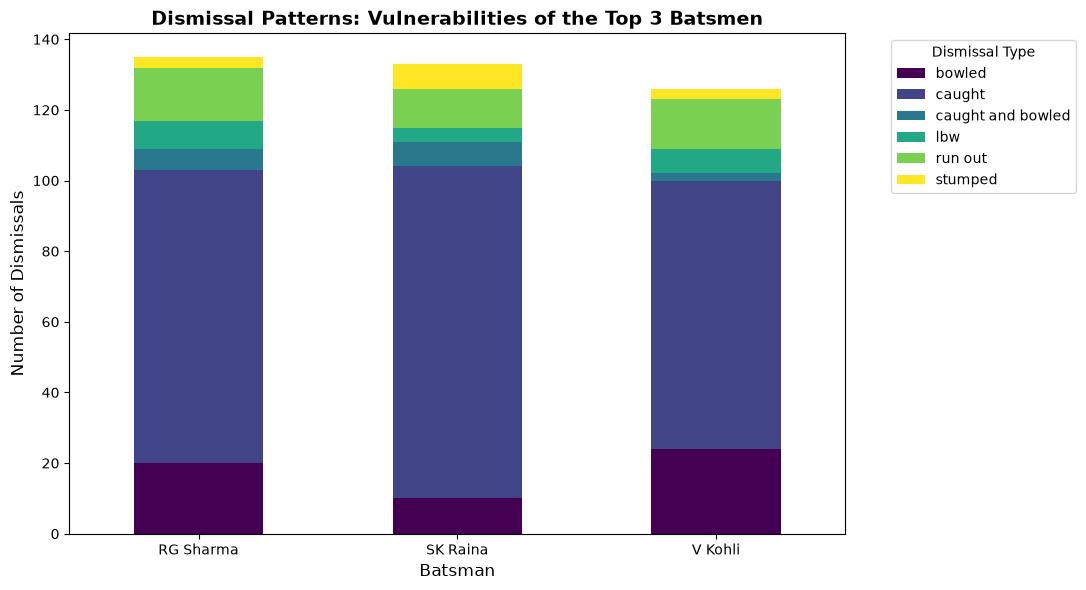

In [37]:

top_3_names = top_10_batsmen.head(3).index.tolist()
dismissals = df[(df['batsman'].isin(top_3_names)) & (df['player_dismissed'].notnull())]
dismissal_counts = dismissals.groupby(['batsman', 'dismissal_kind']).size().unstack(fill_value=0)
dismissal_counts.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='viridis')
plt.title('Dismissal Patterns: Vulnerabilities of the Top 3 Batsmen', fontsize=14, fontweight='bold')
plt.xlabel('Batsman', fontsize=12)
plt.ylabel('Number of Dismissals', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Dismissal Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

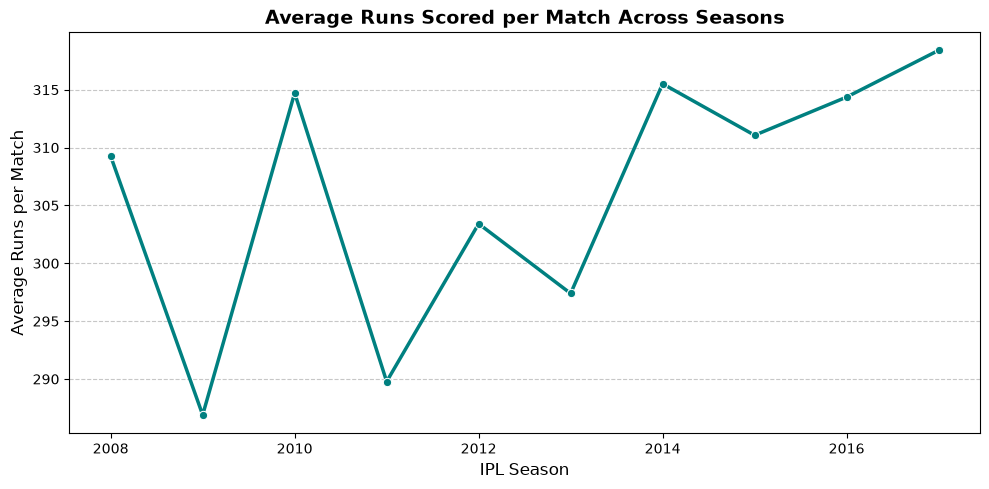

In [38]:

season_runs = df.groupby('season')['total_runs'].sum()
season_matches = matches_only.groupby('season').size()
avg_runs = (season_runs / season_matches).reset_index(name='avg_runs_per_match')
plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_runs, x='season', y='avg_runs_per_match', marker='o', color='teal', linewidth=2.5)
plt.title('Average Runs Scored per Match Across Seasons', fontsize=14, fontweight='bold')
plt.xlabel('IPL Season', fontsize=12)
plt.ylabel('Average Runs per Match', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

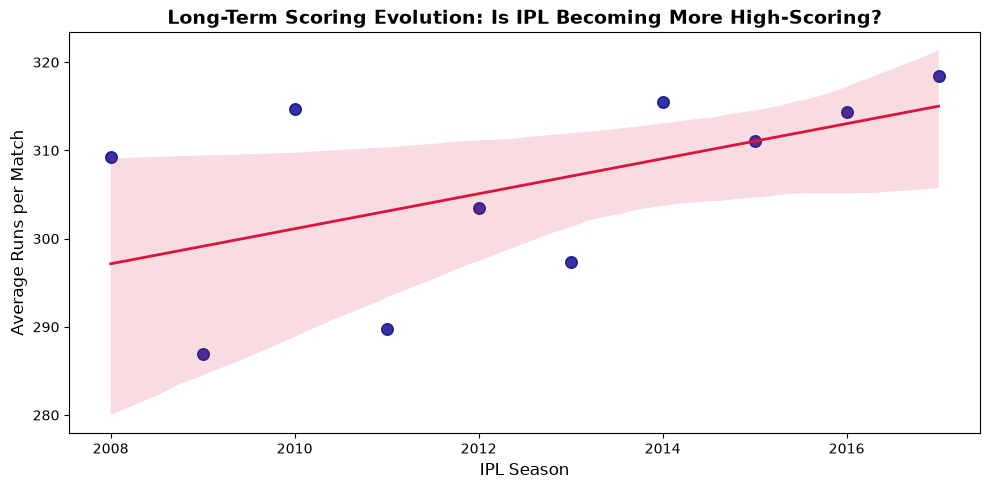

In [39]:

plt.figure(figsize=(10, 5))
sns.regplot(
    data=avg_runs, 
    x='season', 
    y='avg_runs_per_match', 
    scatter_kws={'s': 70, 'color': 'darkblue'}, 
    line_kws={'color': 'crimson', 'linewidth': 2}
)
plt.title('Long-Term Scoring Evolution: Is IPL Becoming More High-Scoring?', fontsize=14, fontweight='bold')
plt.xlabel('IPL Season', fontsize=12)
plt.ylabel('Average Runs per Match', fontsize=12)

plt.tight_layout()
plt.show()

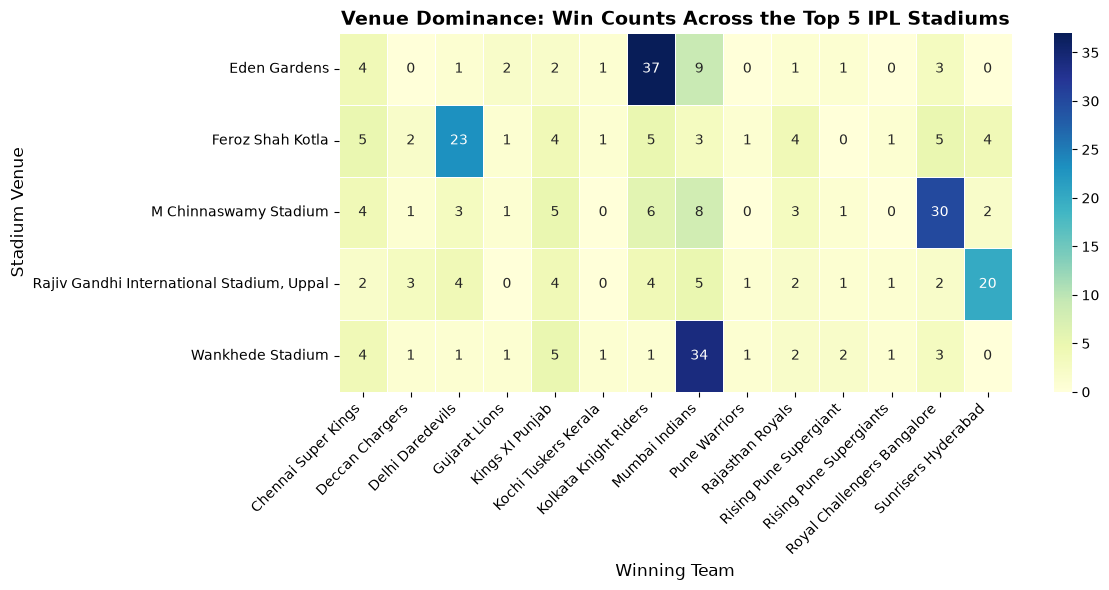

In [40]:
#question 8 
import matplotlib.pyplot as plt
import seaborn as sns

top_5_venues = matches_only['venue'].value_counts().head(5).index
venue_data = matches_only[matches_only['venue'].isin(top_5_venues)]
venue_wins = venue_data.groupby(['venue', 'winner']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(
    venue_wins, 
    cmap='YlGnBu',  
    annot=True,     
    fmt='d',        
    linewidths=0.5   
)
plt.title('Venue Dominance: Win Counts Across the Top 5 IPL Stadiums', fontsize=14, fontweight='bold')
plt.xlabel('Winning Team', fontsize=12)
plt.ylabel('Stadium Venue', fontsize=12)
plt.xticks(rotation=45, ha='right') 

plt.tight_layout()
plt.show()

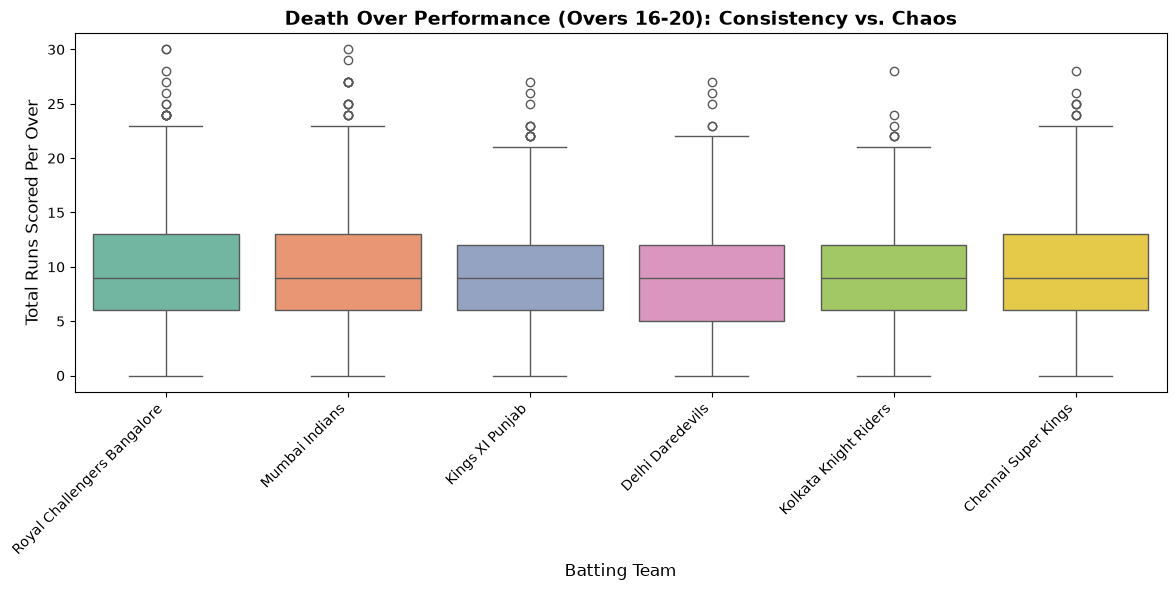

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
death_overs = df[df['over'] >= 16]
top_6_teams = death_overs.groupby('batting_team')['total_runs'].sum().nlargest(6).index
death_overs_top6 = death_overs[death_overs['batting_team'].isin(top_6_teams)]

runs_per_over = death_overs_top6.groupby(['match_id', 'batting_team', 'over'])['total_runs'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=runs_per_over, 
    x='batting_team', 
    y='total_runs', 
    palette='Set2', 
    hue='batting_team', 
    legend=False
)

plt.title('Death Over Performance (Overs 16-20): Consistency vs. Chaos', fontsize=14, fontweight='bold')
plt.xlabel('Batting Team', fontsize=12)
plt.ylabel('Total Runs Scored Per Over', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
#SUMMARY



#Over the years, the IPL has changed a lot. It used to be an equal fight between bowlers and batters, but now it is a high-scoring game where batters dominate.



#By looking at the data for every single ball bowled, this report shows that winning the coin toss does not actually give a team much of an advantage. Instead, true success in the IPL comes down to two main things:



#Winning at home: Teams win much more often in their own stadiums because they know the local pitch and boundary sizes perfectly.



#Smart play in the death overs (16-20): How well a team handles the pressure in the final five overs usually decides the game.



#The Bottom Line: Teams that score a steady, reliable number of runs in the final overs win more consistently than teams that rely on risky, hit-or-miss power hitting.

In [ ]:
#KEY INSIGHTS 



#The Toss Doesn't Matter Much: Our charts show that whether a team chooses to bat or field first, their chances of winning stay right around 50%. The coin toss does not guarantee a win.



#Even Legends Have Weaknesses: When we looked at how the top 3 all-time run-scorers get out, we found they are rarely clean bowled. They mostly get out by being caught, which means opposing teams use smart fielding traps to catch them making mistakes.


#Home Stadium Advantage is Huge: The heatmap proves that top teams win a massive amount of games in their own stadiums. Playing in a familiar ground with the home crowd gives a proven mathematical edge.


#Two Ways to Handle the Death Overs: In the final 5 overs, teams play differently. Teams like CSK are steady and reliable, guaranteeing a safe number of runs. Teams like MI are explosive—they take huge risks, which leads to massive scores but also big collapses.


#Scores are Going Up: Our trend line clearly shows that the average runs scored per match increases almost every year. The game is becoming much more aggressive

In [ ]:
# Recommendation for Team Strategy



#Build a team for your home stadium and the final 5 overs.


#Since the coin toss doesn't give a real advantage, captains shouldn't stress over it.


#Instead, because teams play half their matches at home, coaches should pick bowlers who perfectly match their home pitch (like picking great spinners for a slow home track). 
 

#Most importantly, teams need to invest in a reliable bowling attack that can stay calm and stop runs during the chaotic death overs.

In [ ]:
# Self-Reflection & Missing Data


#The biggest limitation of this dataset is that it only gives us the math, not the environment.


#If I could add one thing to this analysis, it would be weather and pitch reports. For example, the "dew factor" is huge in cricket—if the grass is wet at night, 


#the ball gets slippery and is incredibly hard for spinners to bowl.


#Without knowing the weather or the pitch conditions, we are missing a big piece of the real-world puzzle that decides who wins.